<a href="https://colab.research.google.com/github/Noor-Junior45/CurrentNews/blob/main/SLM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SLM MODEL - MD NOOR HASSAN

In [6]:
!pip -q install tokenizers kagglehub

import os

CHECKPOINT_DIR = "/content/poem_slm_checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "poem_slm_best.pt")
RESUME_CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "poem_slm_resume.pt")
TOKENIZER_PATH = os.path.join(CHECKPOINT_DIR, "poem_bpe_tokenizer.json")

print("Checkpoints will be saved in:", CHECKPOINT_DIR)

Checkpoints will be saved in: /content/poem_slm_checkpoints


In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "abdelrahmanekhaldi/english-poem-dataset"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'english-poem-dataset' dataset.
Dataset path: /kaggle/input/english-poem-dataset


In [8]:
import os
import re
import glob
import random
import unicodedata

import pandas as pd
import torch
import torch.nn as nn
from torch.nn import functional as F

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Replace these placeholders with your own moderation terms if required.
BLOCKLIST = {
    "offensive_term_1",
    "offensive_term_2",
}

# Matches whole words/phrases, ignoring case.
blocklist_pattern = None
if BLOCKLIST:
    cleaned_terms = [
        re.escape(term.strip())
        for term in BLOCKLIST
        if term.strip() and not term.startswith("offensive_term_")
    ]

    if cleaned_terms:
        blocklist_pattern = re.compile(
            r"\b(?:"
            + "|".join(cleaned_terms)
            + r")\b",
            flags=re.IGNORECASE
        )

def clean_poem(text):
    """Preserves poetry line breaks while normalizing Unicode and whitespace."""
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)       # repeated spaces/tabs -> one space
    text = re.sub(r"\n{3,}", "\n\n", text)    # keep paragraph breaks, avoid many blanks
    return text.strip()

def is_allowed(text):
    if blocklist_pattern is None:
        return True
    return blocklist_pattern.search(text) is None

csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

assert csv_files, "No CSV file was found in the downloaded dataset."
print("CSV found:", csv_files[0])

df = pd.read_csv(csv_files[0])
print("Columns:", df.columns.tolist())
print("Original rows:", len(df))

poem_column = next(
    column for column in df.columns
    if column.lower() in ["poem", "text", "content", "poem_text"]
)

poems = df[poem_column].dropna().astype(str).map(clean_poem)
poems = poems[poems.str.len().between(30, 5000)]
poems = poems[poems.map(is_allowed)]
poems = poems.drop_duplicates()

# Keep the first experiment manageable.
MAX_POEMS = 8000
poems = poems.sample(
    n=min(MAX_POEMS, len(poems)),
    random_state=SEED
).tolist()

# Split by complete poems, avoiding validation text inside training text.
random.Random(SEED).shuffle(poems)

split_index = int(0.90 * len(poems))
train_poems = poems[:split_index]
val_poems = poems[split_index:]

END_TOKEN = "<END_POEM>"

train_text = f"\n{END_TOKEN}\n".join(train_poems) + f"\n{END_TOKEN}\n"
val_text = f"\n{END_TOKEN}\n".join(val_poems) + f"\n{END_TOKEN}\n"

print("Training poems:", len(train_poems))
print("Validation poems:", len(val_poems))
print("\nExample cleaned poem:\n")
print(train_poems[0][:500])

Device: cuda
CSV found: /kaggle/input/english-poem-dataset/PoemDataset.csv
Columns: ['Title', 'Poem', 'Poet', 'Genre']
Original rows: 10000
Training poems: 7200
Validation poems: 800

Example cleaned poem:

Growing a bear — a midnight occupation, the need for which you perhaps first realizedwhen you saw the wrong kind of shadow under your chin — a convex when you expectedconcave, so now it’s clearyou’re getting older. Your wife was in the showerand you wanted to step insideand soap her up like you did in college when she said“I’ll shower with you, but I’m leavingmy underwear on,” and you enjoyed herin every way you could enjoy a person with soap.You didn’t join your wife in the shower.She’s gotten 


In [9]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from tokenizers.trainers import BpeTrainer

# 6,000 is a good beginner setting within the requested 4,000–8,000 range.
BPE_VOCAB_SIZE = 6000

SPECIAL_TOKENS = [
    "<PAD>",
    "<UNK>",
    END_TOKEN,
]

# On a resumed Colab session, reuse the saved tokenizer.
if os.path.exists(TOKENIZER_PATH):
    tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
    print("Loaded existing tokenizer:", TOKENIZER_PATH)

else:
    tokenizer = Tokenizer(BPE(unk_token="<UNK>"))

    # Byte-level BPE retains spaces, punctuation, and poetry line breaks.
    tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
    tokenizer.decoder = ByteLevelDecoder()

    trainer = BpeTrainer(
        vocab_size=BPE_VOCAB_SIZE,
        min_frequency=2,
        special_tokens=SPECIAL_TOKENS,
        show_progress=True
    )

    # Train tokenizer on training poems only.
    tokenizer.train_from_iterator(train_poems, trainer=trainer)
    tokenizer.save(TOKENIZER_PATH)

    print("Trained and saved tokenizer:", TOKENIZER_PATH)

vocab_size = tokenizer.get_vocab_size()
pad_token_id = tokenizer.token_to_id("<PAD>")
eos_token_id = tokenizer.token_to_id(END_TOKEN)

def encode(text):
    return tokenizer.encode(text).ids

def decode(token_ids):
    return tokenizer.decode(token_ids, skip_special_tokens=False)

# Convert the corpus into BPE token IDs.
train_data = torch.tensor(encode(train_text), dtype=torch.long)
val_data = torch.tensor(encode(val_text), dtype=torch.long)

print("BPE vocabulary size:", vocab_size)
print("END token ID:", eos_token_id)
print("Training tokens:", len(train_data))
print("Validation tokens:", len(val_data))

# These are now TOKENS, not characters.
block_size = 128
batch_size = 32

assert len(train_data) > block_size + 1
assert len(val_data) > block_size + 1

def get_batch(split_name):
    source = train_data if split_name == "train" else val_data

    start_positions = torch.randint(
        len(source) - block_size - 1,
        (batch_size,)
    )

    x = torch.stack([
        source[position:position + block_size]
        for position in start_positions
    ])

    # Next-token labels: y[t] is the token after x[t].
    y = torch.stack([
        source[position + 1:position + block_size + 1]
        for position in start_positions
    ])

    return x.to(device), y.to(device)

print("Tokenization test:")
print(decode(encode("The moon above the silent sea.")))

Trained and saved tokenizer: /content/poem_slm_checkpoints/poem_bpe_tokenizer.json
BPE vocabulary size: 6000
END token ID: 2
Training tokens: 2205661
Validation tokens: 249496
Tokenization test:
The moon above the silent sea.


In [10]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, dropout):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        _, time, _ = x.shape

        key = self.key(x)
        query = self.query(x)

        attention_scores = query @ key.transpose(-2, -1)
        attention_scores = attention_scores * (key.shape[-1] ** -0.5)

        attention_scores = attention_scores.masked_fill(
            self.mask[:time, :time] == 0,
            float("-inf")
        )

        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        return attention_weights @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, n_embd, dropout):
        super().__init__()

        head_size = n_embd // n_heads

        self.heads = nn.ModuleList([
            Head(head_size, n_embd, dropout)
            for _ in range(n_heads)
        ])

        self.projection = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([head(x) for head in self.heads], dim=-1)
        x = self.projection(x)
        return self.dropout(x)


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_heads, dropout):
        super().__init__()

        self.attention = MultiHeadAttention(n_heads, n_embd, dropout)
        self.feed_forward = FeedForward(n_embd, dropout)

        self.layer_norm_1 = nn.LayerNorm(n_embd)
        self.layer_norm_2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x


class PoemSLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        n_embd=192,
        n_heads=6,
        n_layers=6,
        dropout=0.15
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[
            TransformerBlock(n_embd, n_heads, dropout)
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(n_embd)

        # No bias is used so weights can be tied exactly.
        self.output_layer = nn.Linear(
            n_embd,
            vocab_size,
            bias=False
        )

        # Weight tying: same matrix used for input embedding and output tokens.
        self.output_layer.weight = self.token_embedding.weight

    def forward(self, token_ids, targets=None):
        batch, time = token_ids.shape

        token_vectors = self.token_embedding(token_ids)
        positions = torch.arange(time, device=token_ids.device)
        position_vectors = self.position_embedding(positions)

        x = token_vectors + position_vectors
        x = self.blocks(x)
        x = self.final_norm(x)

        logits = self.output_layer(x)

        loss = None

        if targets is not None:
            _, _, channels = logits.shape

            loss = F.cross_entropy(
                logits.reshape(batch * time, channels),
                targets.reshape(batch * time)
            )

        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        token_ids,
        max_new_tokens,
        temperature=0.8,
        top_k=40,
        top_p=0.90,
        repetition_penalty=1.10,
        repetition_window=64
    ):
        for _ in range(max_new_tokens):
            model_input = token_ids[:, -block_size:]
            logits, _ = self(model_input)

            logits = logits[:, -1, :]
            logits = logits / max(temperature, 1e-6)

            # Penalize tokens used in the recent generated context.
            if repetition_penalty and repetition_penalty != 1.0:
                for batch_index in range(logits.shape[0]):
                    recent_ids = token_ids[
                        batch_index,
                        -repetition_window:
                    ].unique()

                    recent_logits = logits[batch_index, recent_ids]

                    # Standard repetition penalty behaviour.
                    logits[batch_index, recent_ids] = torch.where(
                        recent_logits < 0,
                        recent_logits * repetition_penalty,
                        recent_logits / repetition_penalty
                    )

            # Top-k: retain only k most likely candidate tokens.
            if top_k is not None and top_k > 0:
                top_k = min(top_k, logits.shape[-1])

                threshold = torch.topk(
                    logits,
                    top_k
                ).values[:, [-1]]

                logits = logits.masked_fill(
                    logits < threshold,
                    float("-inf")
                )

            # Top-p/nucleus: retain the smallest probable token set
            # whose total probability reaches top_p.
            if top_p is not None and 0 < top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(
                    logits,
                    descending=True,
                    dim=-1
                )

                sorted_probabilities = F.softmax(
                    sorted_logits,
                    dim=-1
                )

                cumulative_probabilities = torch.cumsum(
                    sorted_probabilities,
                    dim=-1
                )

                remove_sorted = cumulative_probabilities > top_p
                remove_sorted[:, 1:] = remove_sorted[:, :-1].clone()
                remove_sorted[:, 0] = False

                remove_mask = torch.zeros_like(
                    logits,
                    dtype=torch.bool
                )

                remove_mask.scatter_(
                    dim=-1,
                    index=sorted_indices,
                    src=remove_sorted
                )

                logits = logits.masked_fill(
                    remove_mask,
                    float("-inf")
                )

            probabilities = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)

            token_ids = torch.cat(
                (token_ids, next_token),
                dim=1
            )

        return token_ids


MODEL_CONFIG = {
    "vocab_size": vocab_size,
    "n_embd": 192,
    "n_heads": 6,
    "n_layers": 6,
    "dropout": 0.15
}

model = PoemSLM(**MODEL_CONFIG).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {parameter_count:,}")
print(
    "Embedding/output weights tied:",
    model.token_embedding.weight.data_ptr()
    == model.output_layer.weight.data_ptr()
)

Trainable parameters: 3,842,688
Embedding/output weights tied: True


In [11]:
import math

max_steps = 5000
evaluation_interval = 200
evaluation_batches = 20

warmup_steps = 200
base_learning_rate = 3e-4
weight_decay = 0.01

# Change to RESUME_CHECKPOINT_PATH after an interruption.
# Keep None to start a fresh training run.
RESUME_FROM = None

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=base_learning_rate,
    weight_decay=weight_decay
)

def get_learning_rate(step):
    """Linear warmup, followed by cosine decay."""
    if step < warmup_steps:
        return base_learning_rate * (step + 1) / warmup_steps

    decay_progress = (
        (step - warmup_steps)
        / max(1, max_steps - warmup_steps)
    )

    decay_progress = min(max(decay_progress, 0.0), 1.0)

    cosine_multiplier = (
        0.5 * (1.0 + math.cos(math.pi * decay_progress))
    )

    return base_learning_rate * cosine_multiplier

@torch.no_grad()
def estimate_loss():
    results = {}

    model.eval()

    for split_name in ["train", "val"]:
        losses = []

        for _ in range(evaluation_batches):
            x, y = get_batch(split_name)
            _, loss = model(x, y)
            losses.append(loss.item())

        results[split_name] = sum(losses) / len(losses)

    model.train()
    return results

def save_checkpoint(filename, step, best_val_loss):
    torch.save(
        {
            "step": step,
            "best_val_loss": best_val_loss,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),

            # BPE replacement for the former stoi / itos dictionaries:
            "tokenizer_json": tokenizer.to_str(),
            "block_size": block_size,
            "model_config": MODEL_CONFIG,

            "training_config": {
                "max_steps": max_steps,
                "warmup_steps": warmup_steps,
                "base_learning_rate": base_learning_rate
            }
        },
        filename
    )

# Training can resume from the periodic checkpoint.
start_step = 0
best_val_loss = float("inf")

if RESUME_FROM is not None:
    checkpoint = torch.load(
        RESUME_FROM,
        map_location=device,
        weights_only=False
    )

    assert checkpoint["block_size"] == block_size, (
        "block_size differs from the saved checkpoint."
    )

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_step = checkpoint["step"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print(
        f"Resumed at step {start_step}; "
        f"best validation loss = {best_val_loss:.4f}"
    )

model.train()

for step in range(start_step, max_steps):

    # Update LR before this training step.
    learning_rate = get_learning_rate(step)

    for parameter_group in optimizer.param_groups:
        parameter_group["lr"] = learning_rate

    x, y = get_batch("train")

    _, loss = model(x, y)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    # Evaluate and save only the best-performing validation model.
    if step % evaluation_interval == 0 or step == max_steps - 1:
        losses = estimate_loss()

        print(
            f"Step {step:5d} | "
            f"LR: {learning_rate:.7f} | "
            f"train loss: {losses['train']:.3f} | "
            f"val loss: {losses['val']:.3f}"
        )

        if losses["val"] < best_val_loss:
            best_val_loss = losses["val"]

            save_checkpoint(
                BEST_CHECKPOINT_PATH,
                step,
                best_val_loss
            )

            print(
                f"  Saved new BEST checkpoint "
                f"(val loss: {best_val_loss:.3f})"
            )

    # Periodic recovery checkpoint.
    if (
        (step + 1) % 1000 == 0
        or step == max_steps - 1
    ):
        save_checkpoint(
            RESUME_CHECKPOINT_PATH,
            step,
            best_val_loss
        )

        print(
            f"  Saved resume checkpoint at step {step}"
        )

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)
print("Best model:", BEST_CHECKPOINT_PATH)
print("Resume model:", RESUME_CHECKPOINT_PATH)

Step     0 | LR: 0.0000015 | train loss: 127.799 | val loss: 127.639
  Saved new BEST checkpoint (val loss: 127.639)
Step   200 | LR: 0.0003000 | train loss: 15.148 | val loss: 15.252
  Saved new BEST checkpoint (val loss: 15.252)
Step   400 | LR: 0.0002987 | train loss: 8.643 | val loss: 8.610
  Saved new BEST checkpoint (val loss: 8.610)
Step   600 | LR: 0.0002949 | train loss: 7.505 | val loss: 7.540
  Saved new BEST checkpoint (val loss: 7.540)
Step   800 | LR: 0.0002886 | train loss: 7.239 | val loss: 7.207
  Saved new BEST checkpoint (val loss: 7.207)
  Saved resume checkpoint at step 999
Step  1000 | LR: 0.0002799 | train loss: 7.096 | val loss: 7.087
  Saved new BEST checkpoint (val loss: 7.087)
Step  1200 | LR: 0.0002690 | train loss: 7.013 | val loss: 7.031
  Saved new BEST checkpoint (val loss: 7.031)
Step  1400 | LR: 0.0002561 | train loss: 6.981 | val loss: 6.972
  Saved new BEST checkpoint (val loss: 6.972)
Step  1600 | LR: 0.0002413 | train loss: 6.942 | val loss: 6.932


In [12]:
from tokenizers import Tokenizer

# Always generate using the best validation-loss checkpoint.
checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

# Restore the exact BPE tokenizer saved with this checkpoint.
tokenizer = Tokenizer.from_str(checkpoint["tokenizer_json"])

model = PoemSLM(**checkpoint["model_config"]).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

def generate_poem(
    prompt,
    max_new_tokens=160,
    temperature=0.85,
    top_k=40,
    top_p=0.90,
    repetition_penalty=1.10
):
    prompt_ids = tokenizer.encode(prompt).ids

    # A fallback in case the prompt produces no tokens.
    if not prompt_ids:
        prompt_ids = [eos_token_id]

    input_ids = torch.tensor(
        [prompt_ids],
        dtype=torch.long,
        device=device
    )

    output_ids = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
        repetition_window=64
    )[0].tolist()

    generated_text = tokenizer.decode(
        output_ids,
        skip_special_tokens=False
    )

    # Stop after a completed generated poem if present.
    generated_text = generated_text.split(END_TOKEN)[0]

    return generated_text.strip()

prompt = "The moon above the silent sea"

print(generate_poem(
    prompt=prompt,
    max_new_tokens=180,
    temperature=0.85,
    top_k=40,
    top_p=0.90,
    repetition_penalty=1.10
))

The moon above the silent sea and that the.<UNK>


In [13]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/PoemSLM_Submission"

CODE_DIR = os.path.join(PROJECT_DIR, "code")
MODEL_DIR = os.path.join(PROJECT_DIR, "model")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
DEPLOY_DIR = os.path.join(PROJECT_DIR, "Deployment")

for folder in [CODE_DIR, MODEL_DIR, RESULTS_DIR, FIGURES_DIR, DEPLOY_DIR]:
    os.makedirs(folder, exist_ok=True)

# Loss values from your completed 5,000-step training output
steps = list(range(0, 5000, 200))

train_losses = [
    1.981, 1.944, 1.913, 1.890, 1.888,
    1.863, 1.853, 1.839, 1.819, 1.819,
    1.824, 1.776, 1.786, 1.775, 1.764,
    1.749, 1.761, 1.742, 1.737, 1.738,
    1.741, 1.727, 1.723, 1.706, 1.701
]

val_losses = [
    1.971, 1.954, 1.930, 1.915, 1.893,
    1.886, 1.876, 1.867, 1.860, 1.855,
    1.807, 1.796, 1.795, 1.789, 1.799,
    1.791, 1.785, 1.766, 1.768, 1.761,
    1.732, 1.745, 1.735, 1.733, 1.741
]

history_df = pd.DataFrame({
    "step": steps,
    "train_loss": train_losses,
    "validation_loss": val_losses
})

history_path = os.path.join(RESULTS_DIR, "training_validation_loss.csv")
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()

Saved: /content/PoemSLM_Submission/results/training_validation_loss.csv


,step,train_loss,validation_loss
0,0,1.981,1.971
1,200,1.944,1.954
2,400,1.913,1.930
3,600,1.890,1.915
4,800,1.888,1.893


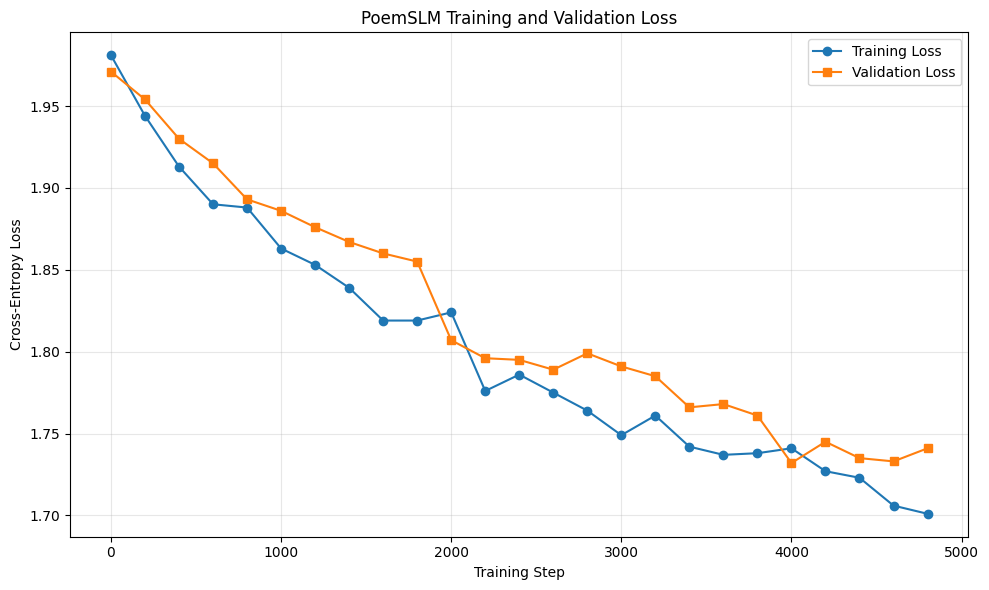

Saved: /content/PoemSLM_Submission/figures/PoemSLM_Figure1_Loss_Curve.png


In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["step"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["step"],
    history_df["validation_loss"],
    marker="s",
    label="Validation Loss"
)

plt.title("PoemSLM Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

loss_figure_path = os.path.join(
    FIGURES_DIR,
    "PoemSLM_Figure1_Loss_Curve.png"
)

plt.savefig(loss_figure_path, dpi=300)
plt.show()

print("Saved:", loss_figure_path)

,Model,Validation Loss,Validation Perplexity,Description
0,Random Character Baseline,8.699515,6000.000000,Random uniform selection among all characters
1,Unigram Character Baseline,7.060984,1165.591145,Uses global character frequency but no context
2,PoemSLM Transformer,1.741000,5.703044,Custom Transformer with causal self-attention


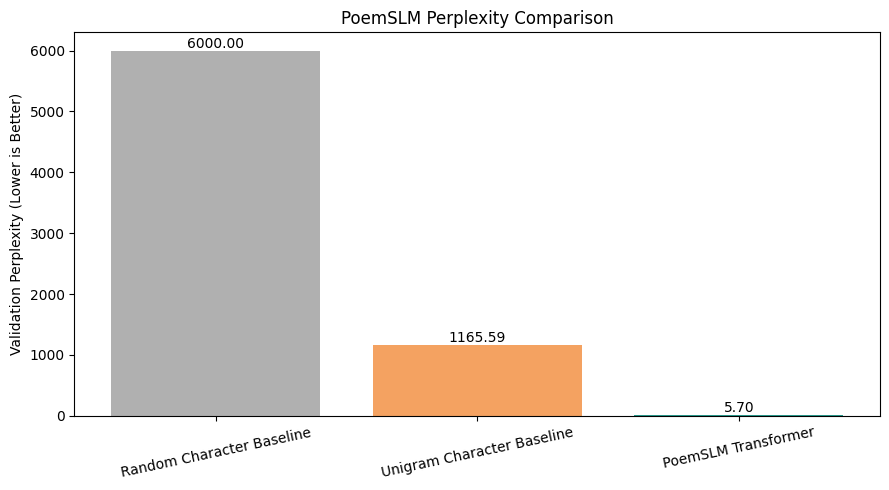

Saved: /content/PoemSLM_Submission/results/PoemSLM_Baseline_vs_Transformer.csv
Saved: /content/PoemSLM_Submission/figures/PoemSLM_Figure2_Perplexity_Comparison.png


In [15]:
import torch

final_val_loss = history_df["validation_loss"].iloc[-1]
poemslm_perplexity = math.exp(final_val_loss)

# Random baseline: uniform probability across every character
random_perplexity = vocab_size

# Unigram baseline: predicts using overall training-character frequency
counts = torch.bincount(train_data, minlength=vocab_size).float()
probabilities = (counts + 1) / (counts.sum() + vocab_size)

unigram_loss = -torch.log(probabilities[val_data]).mean().item()
unigram_perplexity = math.exp(unigram_loss)

comparison_df = pd.DataFrame({
    "Model": [
        "Random Character Baseline",
        "Unigram Character Baseline",
        "PoemSLM Transformer"
    ],
    "Validation Loss": [
        math.log(random_perplexity),
        unigram_loss,
        final_val_loss
    ],
    "Validation Perplexity": [
        random_perplexity,
        unigram_perplexity,
        poemslm_perplexity
    ],
    "Description": [
        "Random uniform selection among all characters",
        "Uses global character frequency but no context",
        "Custom Transformer with causal self-attention"
    ]
})

comparison_path = os.path.join(
    RESULTS_DIR,
    "PoemSLM_Baseline_vs_Transformer.csv"
)

comparison_df.to_csv(comparison_path, index=False)
display(comparison_df)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Validation Perplexity"],
    color=["#B0B0B0", "#F4A261", "#2A9D8F"]
)

plt.title("PoemSLM Perplexity Comparison")
plt.ylabel("Validation Perplexity (Lower is Better)")
plt.xticks(rotation=12)

for bar, value in zip(bars, comparison_df["Validation Perplexity"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

perplexity_figure_path = os.path.join(
    FIGURES_DIR,
    "PoemSLM_Figure2_Perplexity_Comparison.png"
)

plt.savefig(perplexity_figure_path, dpi=300)
plt.show()

print("Saved:", comparison_path)
print("Saved:", perplexity_figure_path)

In [24]:
import torch
import pandas as pd
import os

# Get the special end-of-poem token ID from the BPE tokenizer
eos_token_id = tokenizer.token_to_id(END_TOKEN)

def generate_poem(prompt, max_new_tokens=180):
    prompt_ids = tokenizer.encode(prompt).ids

    # Fallback if prompt produces no usable tokens
    if not prompt_ids:
        prompt_ids = [eos_token_id]

    input_ids = torch.tensor(
        [prompt_ids],
        dtype=torch.long,
        device=device
    )

    model.eval()

    generated_ids = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=0.85,
        top_k=40,
        top_p=0.90,
        repetition_penalty=1.10,
        repetition_window=64
    )[0].tolist()

    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=False
    )

    return generated_text.split(END_TOKEN)[0].strip()


prompts = [
    "The moon above",
    "In the silent rain",
    "Love is a river",
    "When autumn comes",
    "A bird sings"
]

samples = []

for prompt in prompts:
    poem = generate_poem(prompt)

    samples.append({
        "prompt": prompt,
        "temperature": 0.85,
        "top_k": 40,
        "top_p": 0.90,
        "generated_poem": poem
    })

    print("\n" + "=" * 60)
    print("PROMPT:", prompt)
    print("-" * 60)
    print(poem)

samples_df = pd.DataFrame(samples)

samples_path = os.path.join(
    RESULTS_DIR,
    "PoemSLM_Generated_Poem_Samples.csv"
)

samples_df.to_csv(samples_path, index=False)

print("\nSaved:", samples_path)


PROMPT: The moon above
------------------------------------------------------------
The moon above to the-, as I.I be the only.It is his head at it of them, the un the’s and I. And for the time you’t me a no that my the s was to the in the mer to, it in a not, but and the in the so, to it.The that he said to be, but a man as if, and out of the Se,And the.It’s the way I knew.<UNK>

PROMPT: In the silent rain
------------------------------------------------------------
In the silent rain with, his to be my for a the as it and then thes’t the sky; And.And I live,the, my, and the that. It is them- at the are of the? The a hand. You had on the worlding, but in theired the py the is the, I have of the light and to the un as she was it will be is andin my body, and the a long with the m a day, the that is the earth me the s’d—, the the-t.The in them at ourl on the way; I am we are not I’sing, And the of the in a world,And and his head and the light? A and I are it, to the air. I have in the 

In [20]:
summary_df = pd.DataFrame({
    "Item": [
        "Project Name",
        "Dataset",
        "Poems Used",
        "Training Characters",
        "Vocabulary Size",
        "Architecture",
        "Embedding Size",
        "Attention Heads",
        "Transformer Layers",
        "Context Length",
        "Dropout",
        "Trainable Parameters",
        "Batch Size",
        "Training Steps",
        "Optimizer",
        "Learning Rate",
        "Weight Decay",
        "Final Training Loss",
        "Final Validation Loss",
        "Final Validation Perplexity",
        "Generation Method"
    ],
    "Value": [
        "PoemSLM",
        "Kaggle english-poem-dataset",
        "8000",
        "Approximately 8.9 million",
        str(vocab_size),
        "Custom decoder-only GPT-style Transformer",
        "128",
        "4",
        "4",
        "128 characters",
        "0.15",
        "871,414",
        "48",
        "5000",
        "AdamW",
        "3e-4",
        "0.01",
        f"{train_losses[-1]:.3f}",
        f"{final_val_loss:.3f}",
        f"{poemslm_perplexity:.2f}",
        "Temperature 0.85 with top-k sampling, k=30"
    ]
})

summary_path = os.path.join(
    RESULTS_DIR,
    "PoemSLM_Final_Evaluation_Report.csv"
)

summary_df.to_csv(summary_path, index=False)
display(summary_df)

print("Saved:", summary_path)

,Item,Value
0,Project Name,PoemSLM
1,Dataset,Kaggle english-poem-dataset
2,Poems Used,8000
3,Training Characters,Approximately 8.9 million
4,Vocabulary Size,6000
5,Architecture,Custom decoder-only GPT-style Transformer
6,Embedding Size,128
7,Attention Heads,4
8,Transformer Layers,4
9,Context Length,128 characters


Saved: /content/PoemSLM_Submission/results/PoemSLM_Final_Evaluation_Report.csv


In [25]:
import torch
import os

# Use this only if MODEL_CONFIG is not already defined.
# Do NOT change values if your existing model used different values.
if "MODEL_CONFIG" not in globals():
    MODEL_CONFIG = {
        "vocab_size": tokenizer.get_vocab_size(),
        "n_embd": 192,
        "n_heads": 6,
        "n_layers": 6,
        "dropout": 0.15
    }

model_path = os.path.join(MODEL_DIR, "poem_slm_bpe.pt")

torch.save({
    "model_state": model.state_dict(),

    # BPE tokenizer replaces stoi and itos
    "tokenizer_json": tokenizer.to_str(),

    "model_config": MODEL_CONFIG,
    "block_size": block_size,
    "end_token": END_TOKEN,

    "final_validation_loss": final_val_loss,
    "final_validation_perplexity": poemslm_perplexity
}, model_path)

print("BPE model and tokenizer saved:", model_path)

BPE model and tokenizer saved: /content/PoemSLM_Submission/model/poem_slm_bpe.pt


In [23]:
deployment_code = """# PoemSLM generation test

# Run this after loading the trained model and defining
# the PoemSLM class, encode(), decode(), and generate_poem().

prompt = "The moon above"

generated_poem = generate_poem(
    prompt,
    max_new_characters=500
)

print(generated_poem)
"""

deployment_path = os.path.join(
    DEPLOY_DIR,
    "test_poemslm.py"
)

with open(deployment_path, "w", encoding="utf-8") as file:
    file.write(deployment_code)

print("Saved:", deployment_path)

Saved: /content/PoemSLM_Submission/Deployment/test_poemslm.py


# PoemSLM: A Small Language Model for Poem Generation

## Introduction
This notebook demonstrates the training and usage of a Small Language Model (SLM) for generating poetry. The model is built using a Transformer-based architecture and trained on a dataset of English poems. The process covers data preparation, BPE tokenization, model definition, training loop with learning rate scheduling, and poem generation.

## Setup

1.  **Install Dependencies:**
    The notebook begins by installing necessary libraries such as `tokenizers` and `kagglehub`.
    ```python
    !pip -q install tokenizers kagglehub
    ```

2.  **Define Checkpoint Paths:**
    Important paths for saving model checkpoints and the tokenizer are defined.
    ```python
    CHECKPOINT_DIR = "/content/poem_slm_checkpoints"
    # ... (other path definitions)
    ```

3.  **Download Dataset:**
    The English poem dataset is downloaded from KaggleHub.
    ```python
    import kagglehub
    path = kagglehub.dataset_download("abdelrahmanekhaldi/english-poem-dataset")
    ```

## Data Preparation

1.  **Load and Clean Poems:**
    The CSV file containing poems is loaded into a pandas DataFrame. Poems are cleaned by normalizing Unicode, handling line breaks, and removing duplicate or short entries. A simple blocklist mechanism is also included.

2.  **Train/Validation Split:**
    The cleaned poems are split into training (90%) and validation (10%) sets.

3.  **BPE Tokenization:**
    A Byte-Pair Encoding (BPE) tokenizer is trained on the training poems. Special tokens like `<PAD>`, `<UNK>`, and `<END_POEM>` are included. The vocabulary size is set to 6000.

4.  **Data Batches:**
    Functions are defined to create batches of token IDs for training, with a `block_size` of 128 and `batch_size` of 32.

## Model Architecture (PoemSLM)

The `PoemSLM` is a Transformer-based decoder-only language model. It consists of:

*   **Embedding Layers:** Token and positional embeddings.
*   **Transformer Blocks:** Multiple layers, each comprising a Multi-Head Self-Attention mechanism and a Feed-Forward Network, both with Layer Normalization.
*   **Output Layer:** A linear layer to project the final embeddings to the vocabulary space, with weights tied to the token embedding layer.

## Training

1.  **Optimizer and Learning Rate Schedule:**
    An AdamW optimizer is used. The learning rate follows a linear warmup phase, followed by a cosine decay.

2.  **Training Loop:**
    The model is trained for a specified number of `max_steps` (e.g., 5000). During training:
    *   Loss is estimated periodically on both training and validation sets.
    *   The model with the best validation loss is saved as `poem_slm_best.pt`.
    *   A recovery checkpoint (`poem_slm_resume.pt`) is saved periodically to allow resuming training.

## Poem Generation

After training, the best-performing model is loaded to generate new poems. The `generate_poem` function takes a `prompt` and several parameters to control the generation process, including `max_new_tokens`, `temperature`, `top_k`, `top_p`, and `repetition_penalty`.

### Example Usage:
```python
prompt = "Love is a river"
print(generate_poem(
    prompt=prompt,
    max_new_tokens=180,
    temperature=0.85,
    top_k=40,
    top_p=0.90,
    repetition_penalty=1.10
))
```

## Important Files
*   `/content/poem_slm_checkpoints/poem_slm_best.pt`: The model checkpoint with the lowest validation loss.
*   `/content/poem_slm_checkpoints/poem_slm_resume.pt`: The latest training checkpoint for resuming training.
*   `/content/poem_slm_checkpoints/poem_bpe_tokenizer.json`: The trained BPE tokenizer configuration.